In [7]:
from pathlib import Path

In [8]:
OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)

In [9]:
import pandas as pd

df = pd.read_csv(OUTPUT / "dataset_winsize12h.csv")
df

,fold_id,num_events,num_unique_ptids,num_69kv_lines,num_115kv_lines,num_132kv_lines,num_220kv_lines,num_345kv_lines,num_500kv_lines,num_735kv_lines,...,num_events_last_60_min,num_events_last_120_min,node_degree_mean,node_degree_std,node_degree_min,node_degree_max,label_is_auto,label_time_to_event_seconds,label_from_zone,label_to_zone
0,0,1,1,0,1,0,0,0,0,0,...,0,1,3.000000,0.000000,3,3,True,3600.0,12,12
1,3,3,3,0,2,1,0,0,0,0,...,1,1,3.166667,1.674979,2,6,True,1800.0,17,17
2,2,6,6,0,1,4,0,1,0,0,...,0,0,5.750000,3.294566,2,11,True,46501.0,2,2
3,2,8,8,0,0,7,1,0,0,0,...,0,0,4.937500,3.230107,2,11,True,9600.0,22,22
4,1,3,3,0,0,3,0,0,0,0,...,0,0,3.333333,1.885618,2,6,True,18000.0,9,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5978,4,13,13,0,1,3,7,1,1,0,...,5,7,6.038462,4.996004,1,22,True,300.0,21,21
5979,3,19,19,0,8,2,8,1,0,0,...,0,1,7.078947,5.569568,1,22,True,5700.0,12,12
5980,3,3,3,0,1,0,1,1,0,0,...,1,1,4.833333,3.933475,1,13,True,900.0,2,2
5981,1,6,6,0,1,3,1,1,0,0,...,4,4,6.833333,4.669642,1,13,True,0.0,2,2


In [10]:
x = df["label_time_to_event_seconds"].to_numpy()

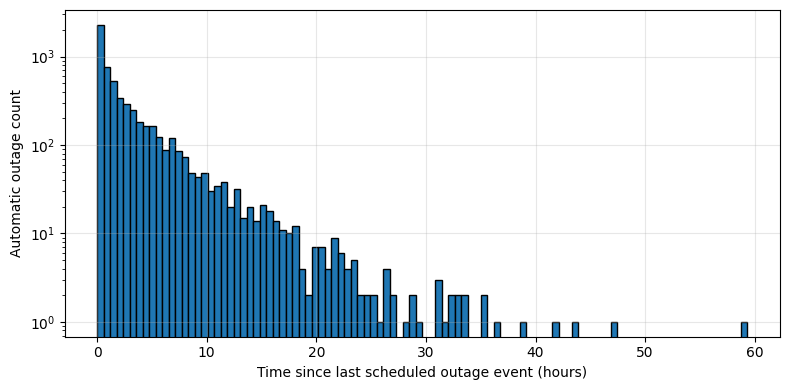

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist([i / 3600 for i in x], bins=100, edgecolor="black")
ax.set_xlabel("Time since last scheduled outage event (hours)")
ax.set_ylabel("Automatic outage count")
ax.set_yscale("log")
# ax.set_xscale("log")

ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    OUTPUT / "auto_outage_time_since_schedule_histogram.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import powerlaw
from typing import Optional


def plot_log_log(
    size_list: list[float],
    xmin: Optional[float] = None,
    xmax: Optional[float] = None,
    dpi: Optional[int] = 300,
    x_label: Optional[str] = "",
    y_label: Optional[str] = "",
    discrete: bool = True,
):
    """Plot CCDF and fit a powerlaw distribution line to the points

    :param size_list: list of initial failure size, cascading failure size, cascading generations, etc.
    """
    fig, ax = plt.subplots(dpi=dpi)
    size_array = np.asarray(size_list, dtype=float)
    size_array = size_array[np.isfinite(size_array) & (size_array > 0)]

    # plot log-log CCDF
    n = len(size_array)
    values, counts = np.unique(size_array, return_counts=True)
    order = np.argsort(values)
    values = values[order]
    counts = counts[order]
    ccdf = np.cumsum(counts[::-1])[::-1] / n
    ax.loglog(values, ccdf, marker="o", linestyle="none")
    # ax.set_xlim(1, 50)

    # fit a line
    fit = powerlaw.Fit(
        size_array,
        discrete=discrete,
        verbose=False,
        survival=True,
        xmin=xmin,
        xmax=xmax,
    )
    print("alpha:", fit.power_law.alpha)
    print("xmin :", fit.power_law.xmin)
    fit.power_law.plot_ccdf(ax=ax, linestyle="--", label="Power-law fit")

    # set labels
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.legend()

    return ax

alpha: 4.127332834858029
xmin : 13.833055555555555


PosixPath('output/auto_outage_time_since_schedule_ccdf_powerlaw_fit.pdf')

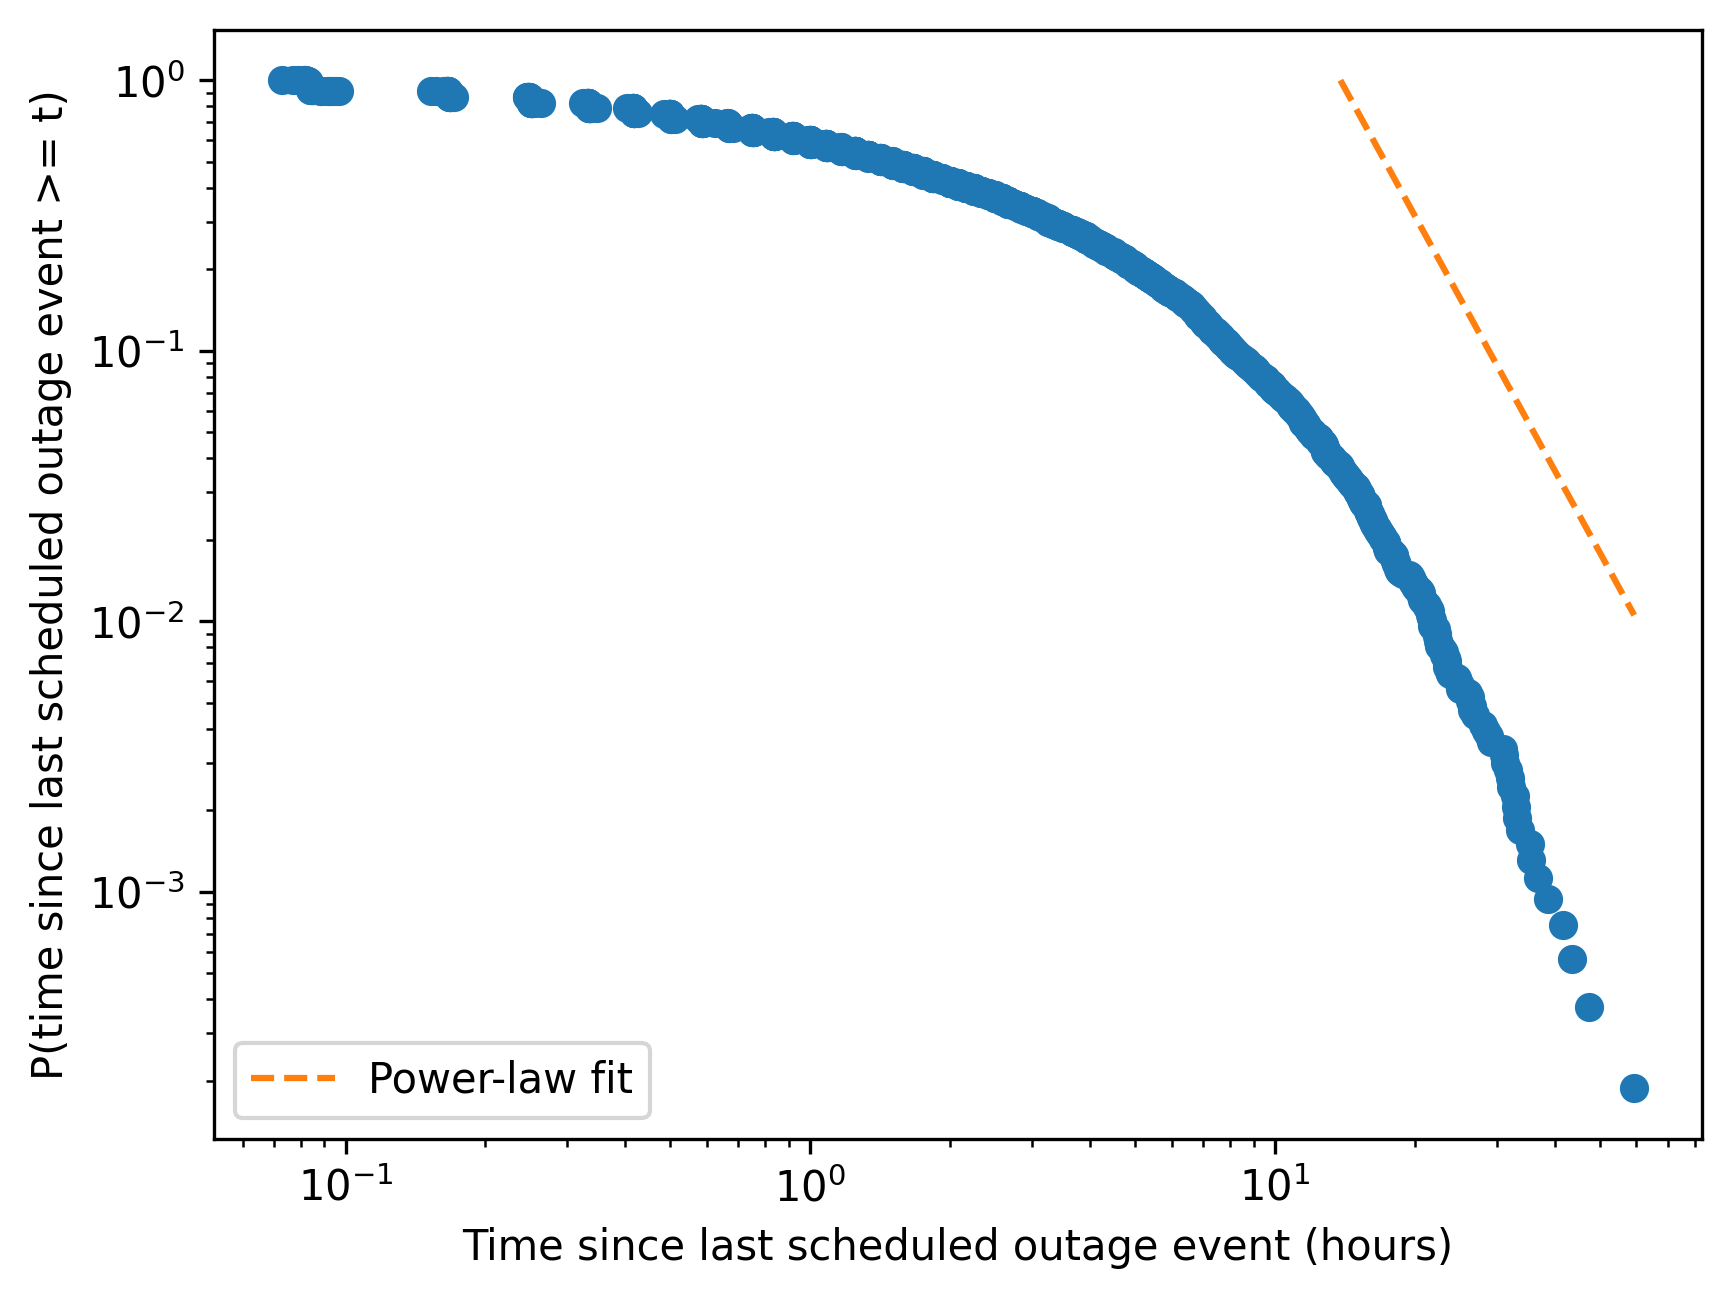

In [13]:
ax = plot_log_log(
    [i / 3600 for i in x],
    discrete=False,
    x_label="Time since last scheduled outage event (hours)",
    y_label="P(time since last scheduled outage event >= t)",
)
plot_path = OUTPUT / "auto_outage_time_since_schedule_ccdf_powerlaw_fit.pdf"

ax.figure.savefig(plot_path, dpi=300, bbox_inches="tight")
plot_path